У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import joblib

In [2]:
raw_df = pd.read_csv("C:/Users/Ivanna/Documents/Dataset/customer_segmentation_train.csv", index_col=0)
raw_df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
ID,,,,,,,,,,
462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [3]:
raw_df.shape

(8068, 10)

In [4]:
raw_df.info()

<class 'pandas.DataFrame'>
Index: 8068 entries, 462809 to 461879
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           8068 non-null   str    
 1   Ever_Married     7928 non-null   str    
 2   Age              8068 non-null   int64  
 3   Graduated        7990 non-null   str    
 4   Profession       7944 non-null   str    
 5   Work_Experience  7239 non-null   float64
 6   Spending_Score   8068 non-null   str    
 7   Family_Size      7733 non-null   float64
 8   Var_1            7992 non-null   str    
 9   Segmentation     8068 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 918.8 KB


In [7]:
raw_df.isna().sum()

Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

In [25]:
(raw_df.isna().mean()*100).round(2)

Gender              0.00
Ever_Married        1.74
Age                 0.00
Graduated           0.97
Profession          1.54
Work_Experience    10.28
Spending_Score      0.00
Family_Size         4.15
Var_1               0.94
Segmentation        0.00
dtype: float64

In [19]:
raw_df.describe()

,Age,Work_Experience,Family_Size
count,8068.000000,7239.000000,7733.000000
mean,43.466906,2.641663,2.850123
std,16.711696,3.406763,1.531413
min,18.000000,0.000000,1.000000
25%,30.000000,0.000000,2.000000
50%,40.000000,1.000000,3.000000
75%,53.000000,4.000000,4.000000
max,89.000000,14.000000,9.000000


In [21]:
raw_df.describe(include='str')

,Gender,Ever_Married,Graduated,Profession,Spending_Score,Var_1,Segmentation
count,8068,7928,7990,7944,8068,7992,8068
unique,2,2,2,9,3,7,4
top,Male,Yes,Yes,Artist,Low,Cat_6,D
freq,4417,4643,4968,2516,4878,5238,2268


**Спостереження**
- Датасет має 10 колонок та 8068 рядків.
- Три числові колонки та 7 категоріальних. З них Gender, Ever_Married, Graduated бінарні.
- Таргет змінна має 4 унікальні значення.
- Пропуски даних у стовпцях складають від 1% до 10%.

## Аналіз числових змінних

In [27]:
raw_df.select_dtypes('number').head()

,Age,Work_Experience,Family_Size
ID,,,
462809,22,1.0,4.0
462643,38,NaN,3.0
466315,67,1.0,1.0
461735,67,0.0,2.0
462669,40,NaN,6.0


In [5]:
# створюємо додаткову функцію для обчислень статистик та візуалізації
def get_stats(data, columns):
    res = data[columns].agg([
        lambda x: x.mean(),
        lambda x: x.mode()[0],
        lambda x: x.median(),
        lambda x: x.isnull().mean() * 100
    ])
    res.index = ['mean', 'mode', 'median', 'missing %']
    sns.boxplot(data[columns])
    plt.show()
    return res.round(2)

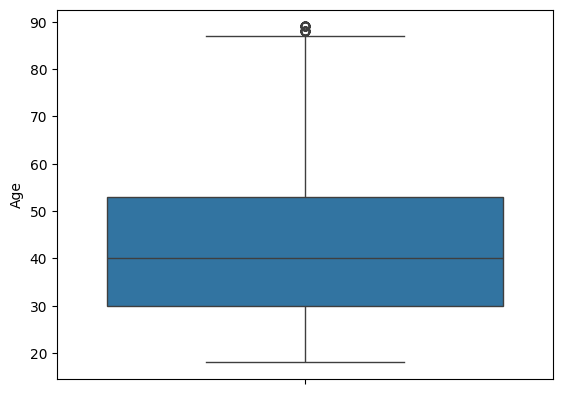

mean         43.47
mode         35.00
median       40.00
missing %     0.00
Name: Age, dtype: float64

In [44]:
get_stats(raw_df, 'Age')

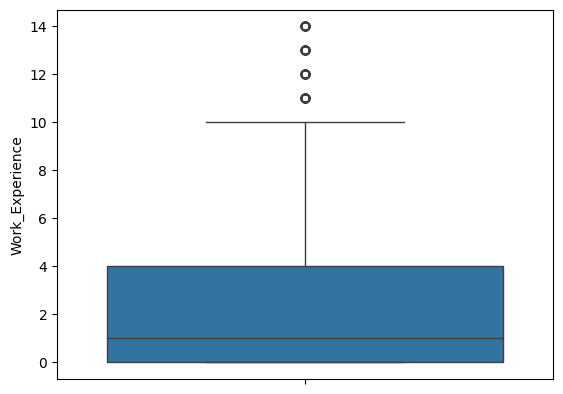

mean          2.64
mode          1.00
median        1.00
missing %    10.28
Name: Work_Experience, dtype: float64

In [37]:
get_stats(raw_df, 'Work_Experience')

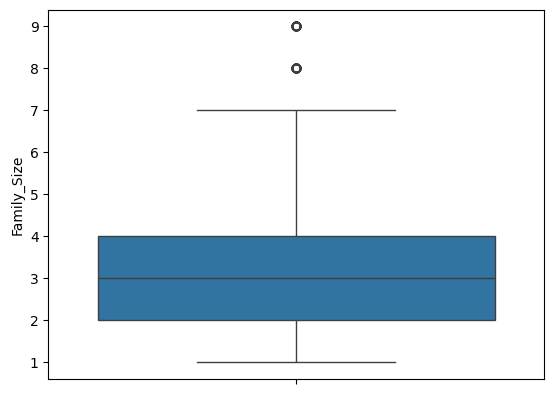

mean         2.85
mode         2.00
median       3.00
missing %    4.15
Name: Family_Size, dtype: float64

In [45]:
get_stats(raw_df, 'Family_Size')

**Спостереження**
- Дві числові колонки `Work_Experience` та `Family_Size` мають пропущені дані. Для обох можна використати імпутацію зі стратегією median.

## Аналіз категоріальних змінних

In [6]:
raw_df.select_dtypes('str').head()

,Gender,Ever_Married,Graduated,Profession,Spending_Score,Var_1,Segmentation
ID,,,,,,,
462809,Male,No,No,Healthcare,Low,Cat_4,D
462643,Female,Yes,Yes,Engineer,Average,Cat_4,A
466315,Female,Yes,Yes,Engineer,Low,Cat_6,B
461735,Male,Yes,Yes,Lawyer,High,Cat_6,B
462669,Female,Yes,Yes,Entertainment,High,Cat_6,A


In [7]:
# створюємо додаткову функцію для обчислень к-ты категорыальних значень та візуалізації
def get_categorical_stats(data, column):
    res = data[column].agg([
        lambda x: x.mode()[0],
        lambda x: x.isnull().mean() * 100
    ])
    res.index = ['mode', 'missing %']
    display(data[column].value_counts())
    plt.figure(figsize = (6, 4))
    sns.countplot(data = data, x = column, hue=column, palette='muted', legend=False, width=0.4)
    plt.title(f"Розподіл значень у колонці {column}")
    plt.xticks(rotation = 90)
    plt.show()
    return res

Gender
Male      4417
Female    3651
Name: count, dtype: int64

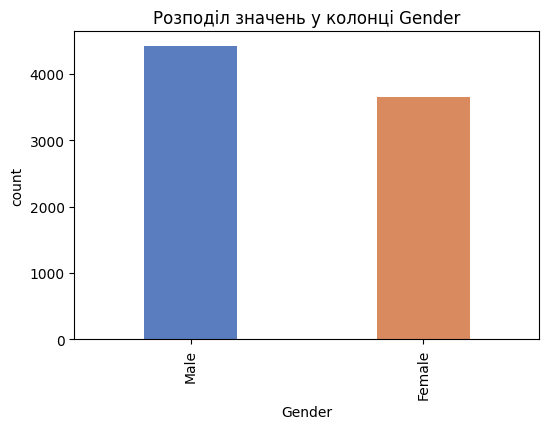

mode         Male
missing %     0.0
Name: Gender, dtype: object

In [130]:
get_categorical_stats(raw_df, 'Gender')

Ever_Married
Yes    4643
No     3285
Name: count, dtype: int64

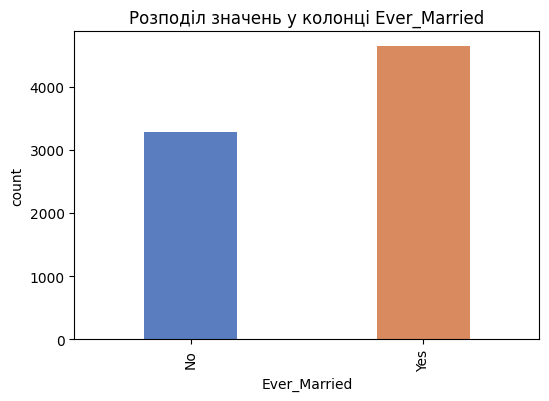

mode             Yes
missing %    1.73525
Name: Ever_Married, dtype: object

In [131]:
get_categorical_stats(raw_df, 'Ever_Married')

Graduated
Yes    4968
No     3022
Name: count, dtype: int64

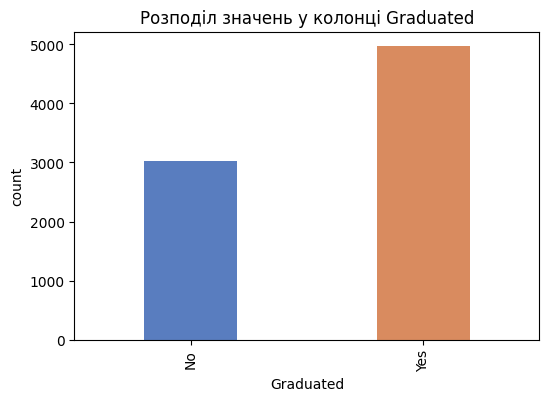

mode              Yes
missing %    0.966782
Name: Graduated, dtype: object

In [132]:
get_categorical_stats(raw_df, 'Graduated')

Profession
Artist           2516
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
Name: count, dtype: int64

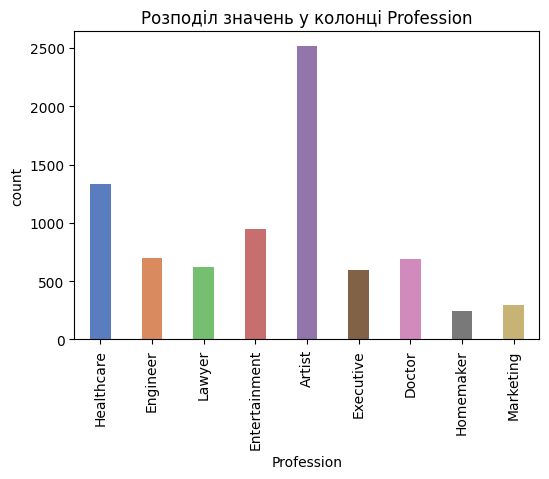

mode           Artist
missing %    1.536936
Name: Profession, dtype: object

In [133]:
get_categorical_stats(raw_df, 'Profession')

Spending_Score
Low        4878
Average    1974
High       1216
Name: count, dtype: int64

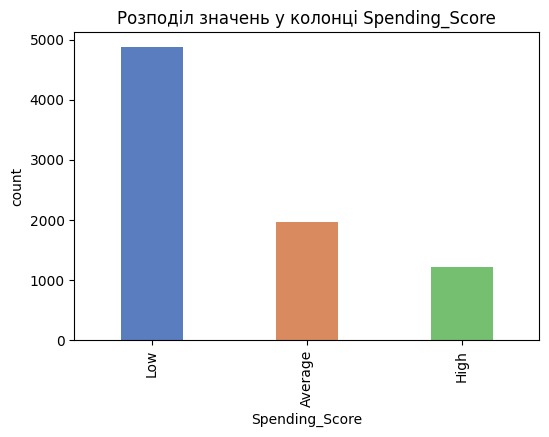

mode         Low
missing %    0.0
Name: Spending_Score, dtype: object

In [134]:
get_categorical_stats(raw_df, 'Spending_Score')

Var_1
Cat_6    5238
Cat_4    1089
Cat_3     822
Cat_2     422
Cat_7     203
Cat_1     133
Cat_5      85
Name: count, dtype: int64

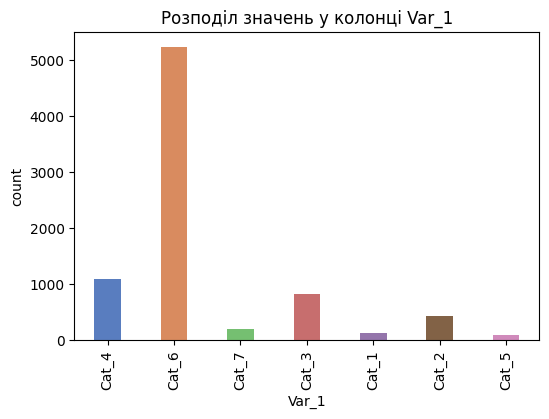

mode            Cat_6
missing %    0.941993
Name: Var_1, dtype: object

In [135]:
get_categorical_stats(raw_df, 'Var_1')

Segmentation
D    2268
A    1972
C    1970
B    1858
Name: count, dtype: int64

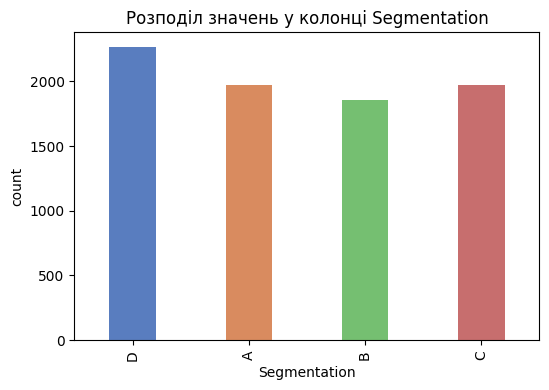

mode           D
missing %    0.0
Name: Segmentation, dtype: object

In [8]:
get_categorical_stats(raw_df, 'Segmentation')

**Спостереження**
- В категоріальних стовпцях пропусків не більше 2%. Можна використати стратегію `most_frequent` для імпутації.

In [9]:
raw_df.columns

Index(['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='str')

In [10]:
train_df, test_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df.Segmentation)

In [11]:
train_df.shape, test_df.shape

((6454, 10), (1614, 10))

In [12]:
train_df.Segmentation.value_counts(normalize=True)

Segmentation
D    0.281066
A    0.244500
C    0.244190
B    0.230245
Name: proportion, dtype: float64

In [13]:
test_df.Segmentation.value_counts(normalize=True)

Segmentation
D    0.281289
A    0.244114
C    0.244114
B    0.230483
Name: proportion, dtype: float64

In [14]:
input_cols = list(raw_df.columns)[:-1]
target_col = list(raw_df.columns)[-1]
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
test_inputs, test_targets = test_df[input_cols], test_df[target_col]

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes('number').columns.tolist()
categorical_cols = train_inputs.select_dtypes('str').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='if_binary'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

preprocessor.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [15]:
train_inputs_transform = preprocessor.fit_transform(train_inputs)
test_inputs_transform = preprocessor.transform(test_inputs)

In [16]:
train_inputs_transform.shape, test_inputs_transform.shape

((6454, 25), (1614, 25))

**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [17]:
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTETomek

In [18]:
train_inputs.columns

Index(['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1'],
      dtype='str')

In [19]:
train_inputs_transform.columns

Index(['num__Age', 'num__Work_Experience', 'num__Family_Size',
       'cat__Gender_Male', 'cat__Ever_Married_Yes', 'cat__Graduated_Yes',
       'cat__Profession_Artist', 'cat__Profession_Doctor',
       'cat__Profession_Engineer', 'cat__Profession_Entertainment',
       'cat__Profession_Executive', 'cat__Profession_Healthcare',
       'cat__Profession_Homemaker', 'cat__Profession_Lawyer',
       'cat__Profession_Marketing', 'cat__Spending_Score_Average',
       'cat__Spending_Score_High', 'cat__Spending_Score_Low',
       'cat__Var_1_Cat_1', 'cat__Var_1_Cat_2', 'cat__Var_1_Cat_3',
       'cat__Var_1_Cat_4', 'cat__Var_1_Cat_5', 'cat__Var_1_Cat_6',
       'cat__Var_1_Cat_7'],
      dtype='str')

In [20]:
categorical_cols

['Gender',
 'Ever_Married',
 'Graduated',
 'Profession',
 'Spending_Score',
 'Var_1']

In [22]:
# SMOTENC
categorical_indices = [i for i, col in enumerate(train_inputs_transform.columns) if col.startswith('cat__')]
smotenc = SMOTENC(categorical_features=categorical_indices, random_state=0)

X_train_smotenc, y_train_smotenc = smotenc.fit_resample(train_inputs_transform, train_targets)

In [23]:
# SMOTE-Tomek
smotetomek = SMOTETomek(random_state=0)
X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(train_inputs_transform, train_targets)

**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

In [26]:
from sklearn.metrics import classification_report, precision_score, recall_score
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

In [28]:
# модель на оригінальних даних
log_reg = LogisticRegression(solver='liblinear', random_state=42)
ovr_model = OneVsRestClassifier(log_reg)

ovr_model.fit(train_inputs_transform, train_targets)
ovr_predictions = ovr_model.predict(test_inputs_transform)

print(classification_report(test_targets, ovr_predictions))

              precision    recall  f1-score   support

           A       0.42      0.45      0.43       394
           B       0.39      0.17      0.23       372
           C       0.49      0.62      0.55       394
           D       0.65      0.75      0.70       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.48      1614
weighted avg       0.49      0.51      0.49      1614



In [31]:
# модель на даних збалансованих з SMOTENC
ovr_smotenc_model = ovr_model.fit(X_train_smotenc, y_train_smotenc)
ovr_smotenc_predictions = ovr_model.predict(test_inputs_transform)

print(classification_report(test_targets, ovr_smotenc_predictions))

              precision    recall  f1-score   support

           A       0.42      0.48      0.45       394
           B       0.39      0.23      0.29       372
           C       0.50      0.58      0.53       394
           D       0.68      0.72      0.70       454

    accuracy                           0.52      1614
   macro avg       0.50      0.50      0.49      1614
weighted avg       0.50      0.52      0.50      1614



In [32]:
# модель на даних збалансованих з SMOTE-Tomek
ovr_smotetomek_model = ovr_model.fit(X_train_smotetomek, y_train_smotetomek)

ovr_smotetomek_predictions = ovr_smotetomek_model.predict(test_inputs_transform)

print(classification_report(test_targets, ovr_smotetomek_predictions))

              precision    recall  f1-score   support

           A       0.42      0.50      0.45       394
           B       0.40      0.24      0.30       372
           C       0.50      0.58      0.54       394
           D       0.68      0.70      0.69       454

    accuracy                           0.51      1614
   macro avg       0.50      0.50      0.49      1614
weighted avg       0.51      0.51      0.50      1614



**Спостереження**
- Я вибрала метрику macro avg f1-score для порівняння результатів, оскільки вона враховує незбалансованість класів та збалансовано враховує як prcision так і recall.
- Три моделі показали схожий результат метрики - 0.49 та 0.48. Вважаю що це незадовільний результат і треба покращувати моделі. Зазначу, що найгірше модель перфомить на класі B, оскільки його екземплярів найменше у даних.
- Причиною схожих низьких результатів у трьох моделей - надостатньо тренувальних даних, на яких можна навчитись якісно розпізнавати всі 4 класи.